# Computing RNA velocity using scVelo - dynamical Model

In [ ]:
import scvelo as scv
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import warnings
warnings.filterwarnings('ignore')

scv.logging.print_version()
scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.set_figure_params('scvelo')  # for beautified visualization

Running scvelo 0.3.1 (python 3.11.5) on 2024-02-19 11:01.


ERROR: XMLRPC request failed [code: -32500]
RuntimeError: PyPI no longer supports 'pip search' (or XML-RPC search). Please use https://pypi.org/search (via a browser) instead. See https://warehouse.pypa.io/api-reference/xml-rpc.html#deprecated-methods for more information.


In [ ]:
# Load anndata file
adata = scv.read("../seurat_objects/timecourse-d7911-renamed-merged.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

## Prepare the Data¶

In [ ]:
warnings.filterwarnings('ignore')
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=6000)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
adata

Filtered out 17548 genes that are detected 20 counts (shared).
Normalized count data: spliced, unspliced.
Extracted 6000 highly variable genes.


/home/wafulae/miniconda3/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.
computing neighbors
    finished (0:01:06) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:57) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


AnnData object with n_obs × n_vars = 148750 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'neighbors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

## Estimate RNA velocity

In [ ]:
# # Estimate RNA velocity using dynamical model
#warnings.filterwarnings('ignore')
scv.tl.recover_dynamics(adata, n_jobs=60)
scv.tl.velocity(adata, mode='dynamical', n_jobs=60)
scv.tl.velocity_graph(adata, n_jobs=60)
adata

recovering dynamics (using 60/192 cores)


  0%|          | 0/353 [00:00<?, ?gene/s]

    finished (1:26:27) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:02:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 60/192 cores)


  0%|          | 0/148750 [00:00<?, ?cells/s]

    finished (0:22:50) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


AnnData object with n_obs × n_vars = 148750 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'neighbors', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    varm: 'loss'
    layers: 'ambiguous', 'mat

## Project the velocities

computing velocity embedding
    finished (0:00:37) --> added
    'velocity_umap_integrated', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_umap_cell_type_velocities.png


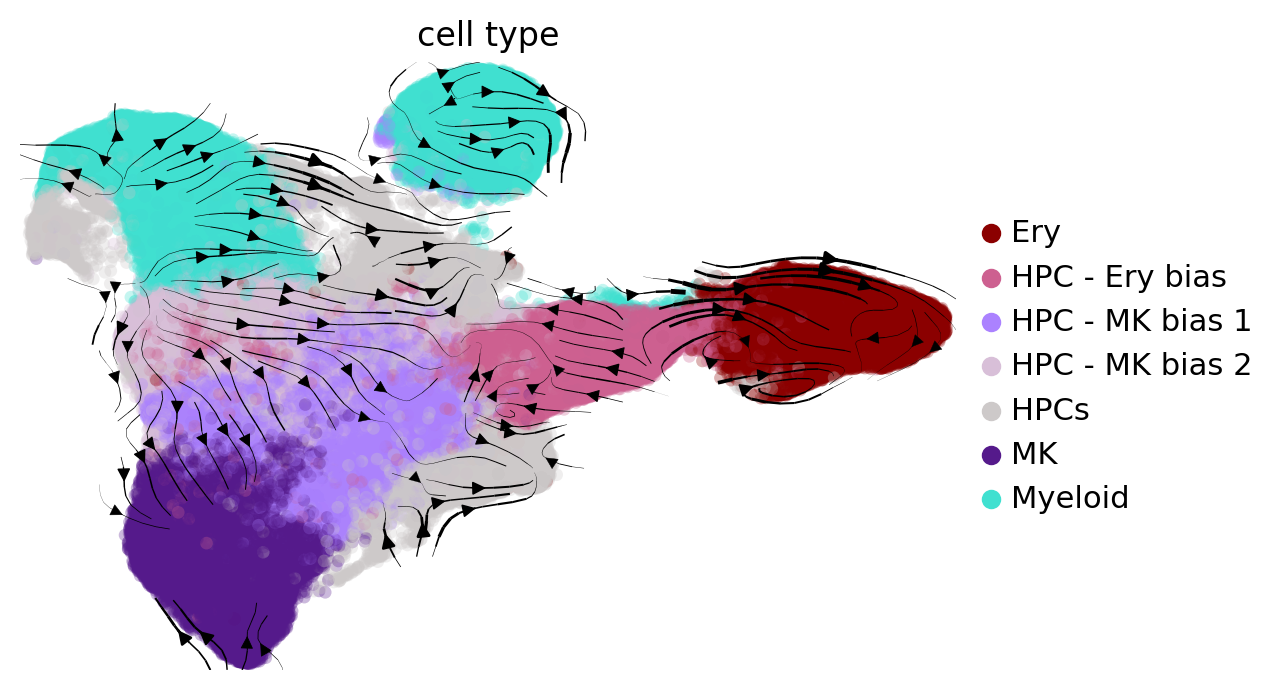

In [ ]:
warnings.filterwarnings('ignore')
scv.pl.velocity_embedding_stream(adata, basis='umap_integrated', color='cell_type', legend_loc="right",
                                 sort_order = False, save = "umap_cell_type_velocities.png")

saving figure to file ./figures/scvelo_umap_cell_type_time.png


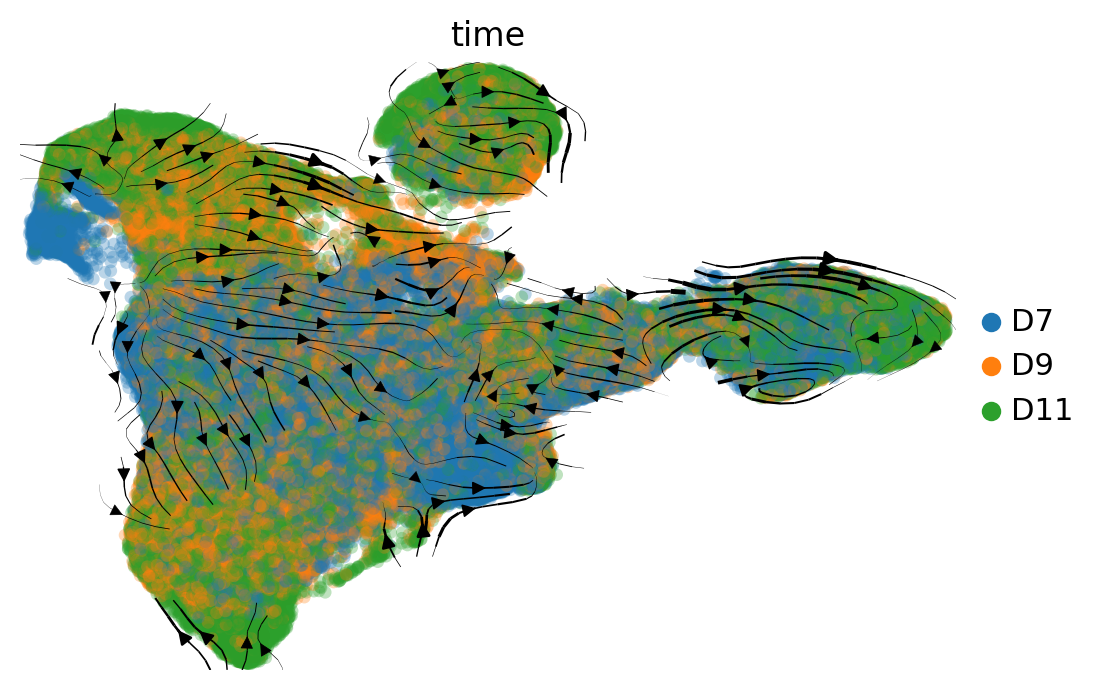

In [ ]:
warnings.filterwarnings('ignore')
scv.pl.velocity_embedding_stream(adata, basis='umap_integrated', color='time', legend_loc="right",
                                 sort_order = False, save = "umap_cell_type_time.png")

## Kinetic rate paramters¶

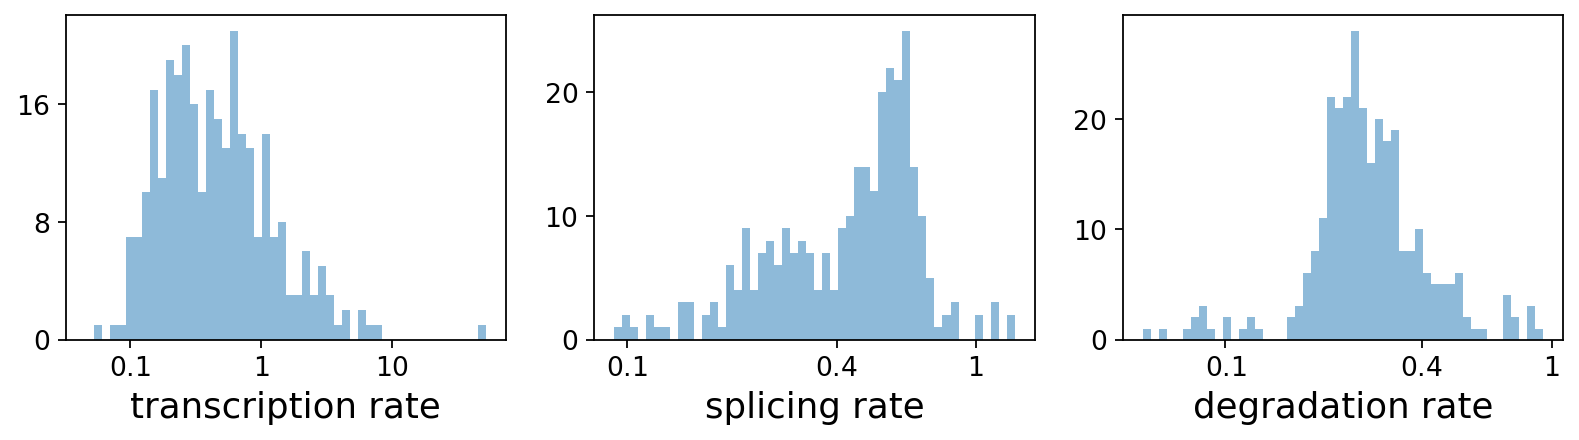

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
TNFRSF4,0.010719,0.209258,3.728528,0.261557,2.355913,0.227230,0.014415,0.080304,1.210424e-13,0.0,0.0,0.424325,0.055795,0.303669,1.536392,1.280640
SMIM1,0.046991,0.723075,11.244388,0.301731,8.129160,0.038841,0.021178,0.553415,1.329429e-01,0.0,0.0,0.476534,0.073889,1.781010,1.881696,1.992006
PLEKHG5,0.026246,0.090774,0.962826,0.178619,11.980410,0.567594,0.030386,0.084318,9.538671e-06,0.0,0.0,0.464784,0.094290,0.401662,5.200392,2.470289
SRM,0.038010,0.834489,9.323225,0.227777,6.588498,0.031710,0.029964,0.439402,1.864818e-01,0.0,0.0,0.454392,0.096363,1.786604,1.577022,1.572881
DHRS3,0.175416,0.108502,0.708119,0.298138,7.148305,0.792975,0.051559,0.082305,2.077903e-01,0.0,0.0,0.269418,0.151752,0.255408,1.074755,1.932252


In [ ]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]

kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

## Latent time¶

computing terminal states
    identified 9 regions of root cells and 3 regions of end points .
    finished (0:03:18) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:01:12) --> added 
    'latent_time', shared time (adata.obs)
saving figure to file ./figures/scvelo_umap_latent_time.png


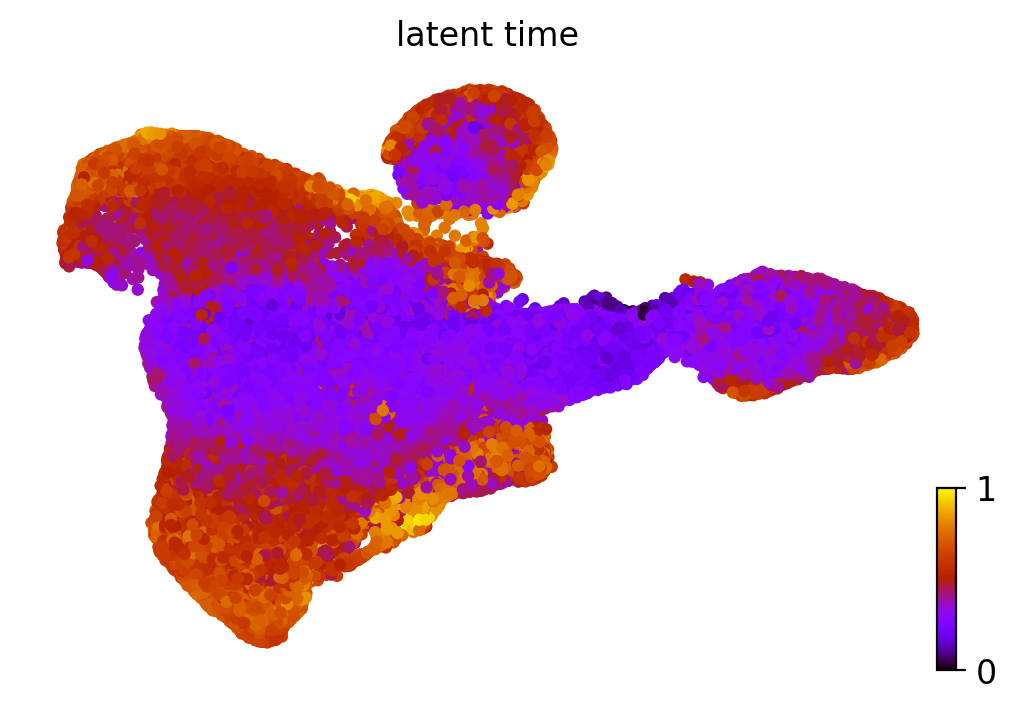

AnnData object with n_obs × n_vars = 148750 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'neighbors', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap_integrate

In [ ]:
warnings.filterwarnings('ignore')
scv.tl.latent_time(adata)
scv.pl.scatter(adata, color='latent_time', basis='umap_integrated', color_map='gnuplot', size=80,
               legend_loc="right", sort_order = False, save = "umap_latent_time.png")
adata

saving figure to file ./figures/scvelo_heatmap_umap_latent_time_heatmap.png


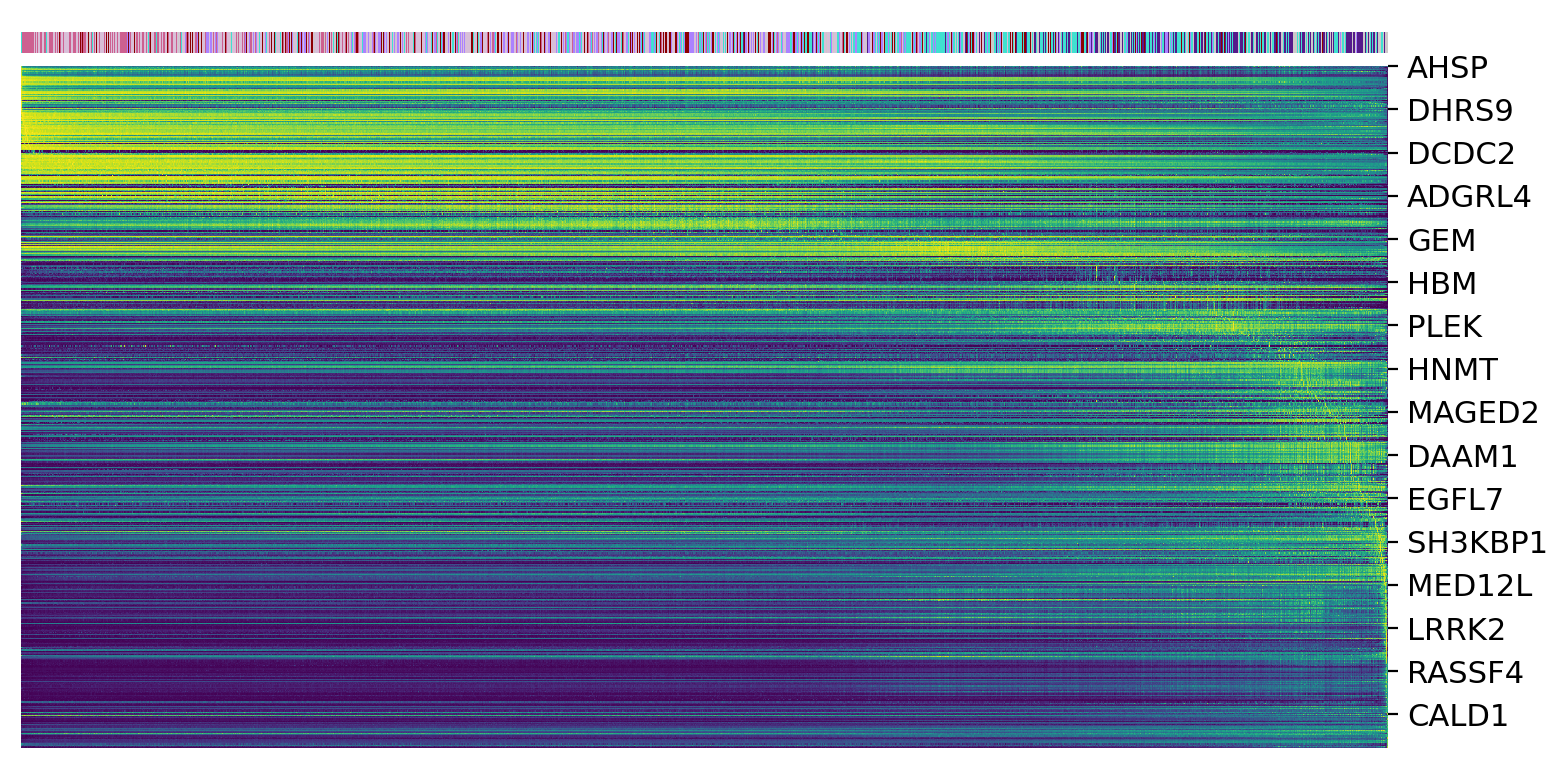

In [ ]:
# top genes
warnings.filterwarnings('ignore')
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index[:600]
scv.pl.heatmap(adata, var_names=top_genes, sortby='latent_time', col_color='cell_type', n_convolve=100,
              save = "umap_latent_time_heatmap.png")

## Top-likelihood genes¶

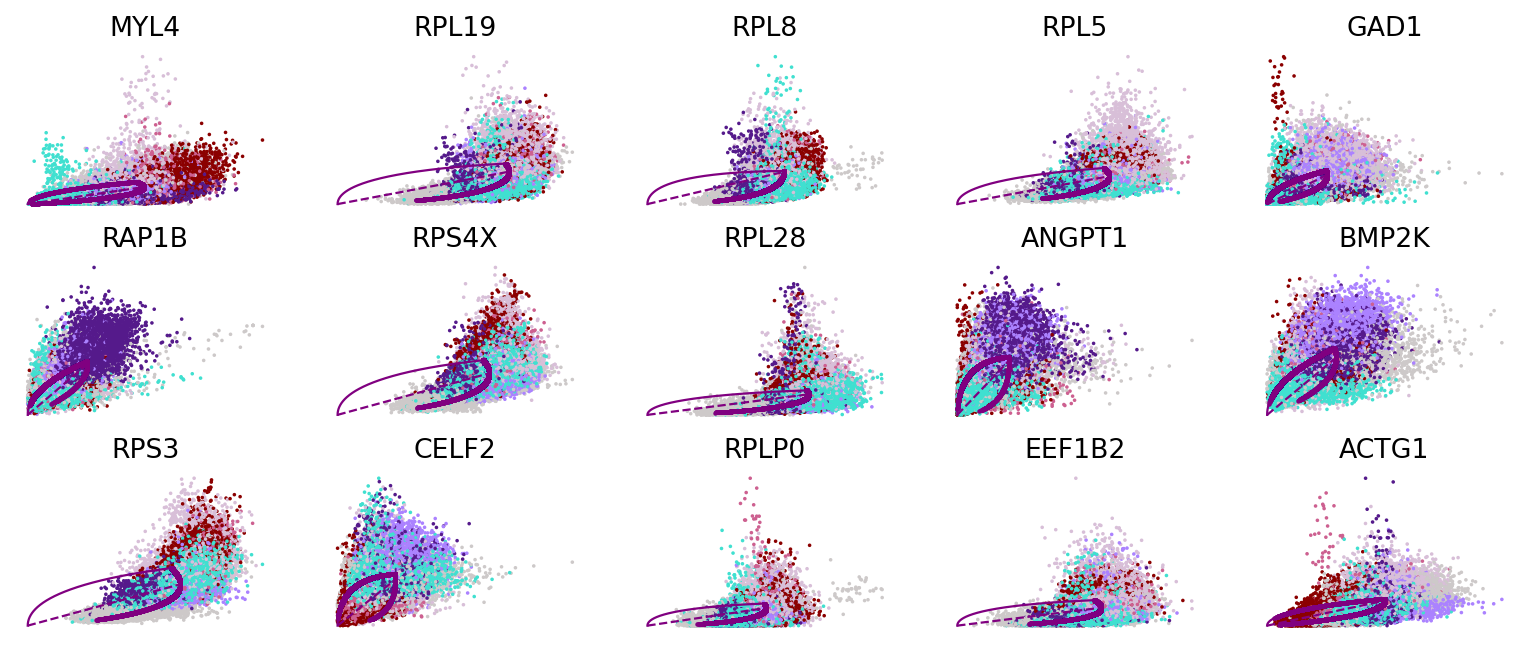

In [ ]:
# top 15 driver genes
warnings.filterwarnings('ignore')
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.scatter(adata, basis=top_genes[:15], ncols=5, frameon=False, color='cell_type')

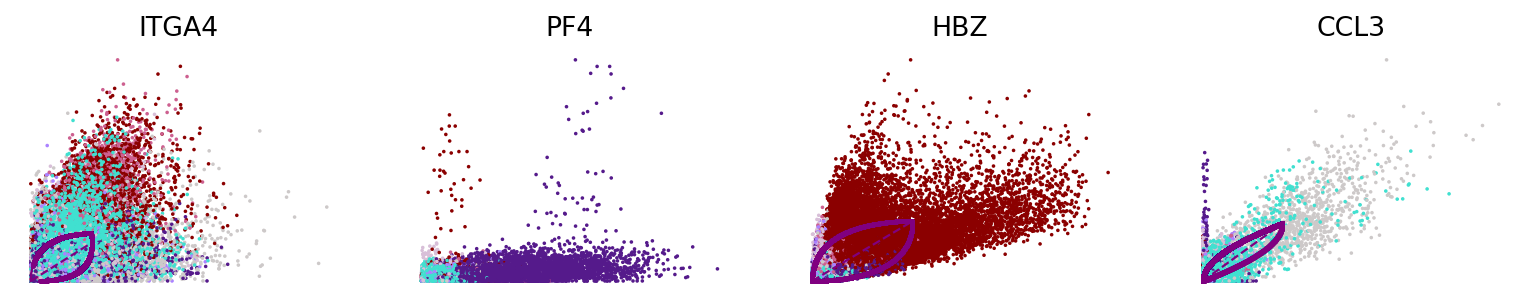

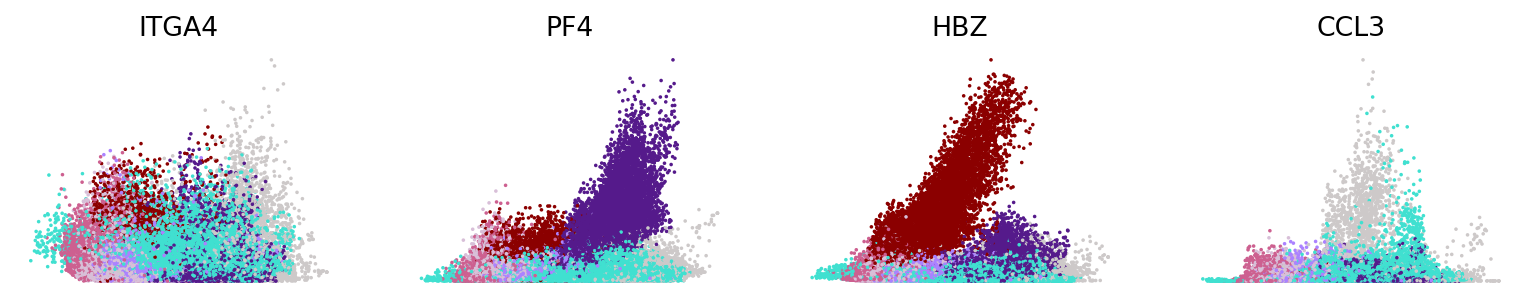

In [ ]:
# markers of interest
warnings.filterwarnings('ignore')
var_names = ['ITGA4',  'PF4', 'HBZ', 'CCL3']
scv.pl.scatter(adata, var_names, frameon=False, color='cell_type')
scv.pl.scatter(adata, x='latent_time', y=var_names, frameon=False, color='cell_type')

## Cluster-specific top-likelihood genes

In [ ]:
# cluster specific driver genes
warnings.filterwarnings('ignore')
scv.tl.rank_dynamical_genes(adata, groupby='cell_type')
df = scv.get_df(adata, 'rank_dynamical_genes/names')
df.head(5)

ranking genes by cluster-specific likelihoods
    finished (0:01:24) --> added 
    'rank_dynamical_genes', sorted scores by group ids (adata.uns)


,Ery,HPC - Ery bias,HPC - MK bias 1,HPC - MK bias 2,HPCs,MK,Myeloid
0,RPS4X,RPS4X,RPS3,PRKAR2B,RPS3,RPS4X,RPS4X
1,RPL19,PRKAR2B,RPS4X,RPS3,RACK1,BMP2K,RPS3
2,PRKAR2B,RPS3,GAD1,RPS4X,RPL19,CELF2,RACK1
3,RPS3,RPL5,RACK1,GAD1,PRKAR2B,PDLIM1,RPS13
4,RPL5,RACK1,RPL5,RACK1,RPS4X,RPL26,RPL26


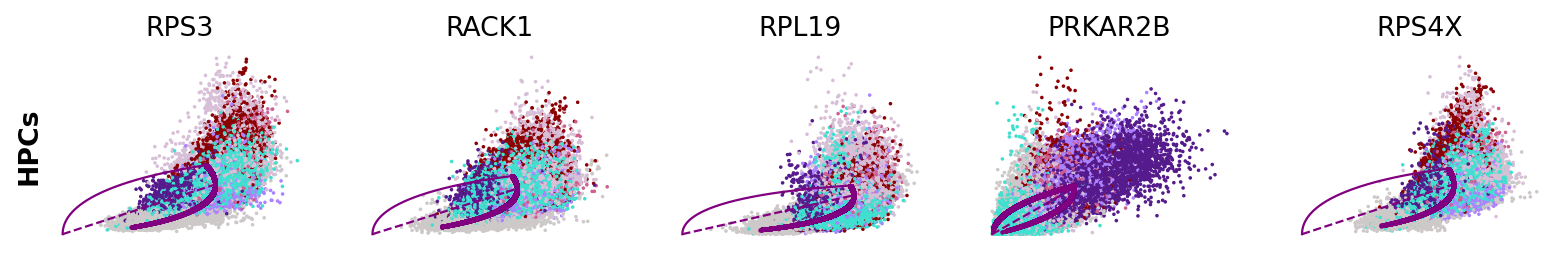

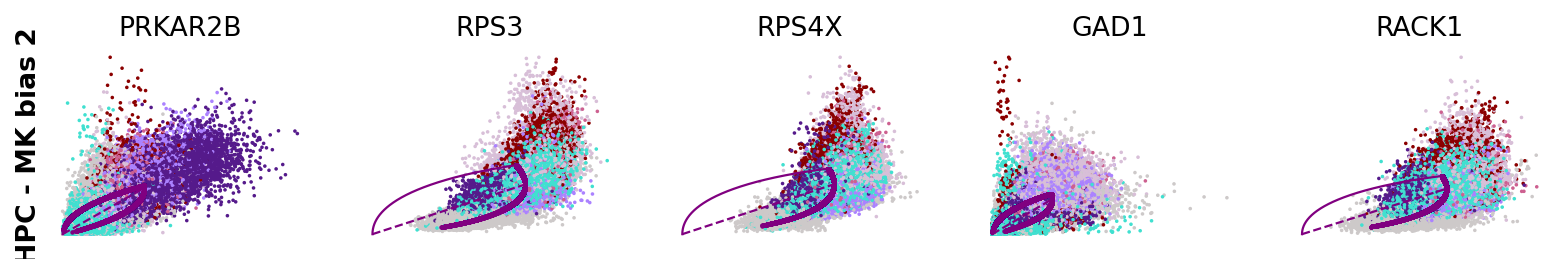

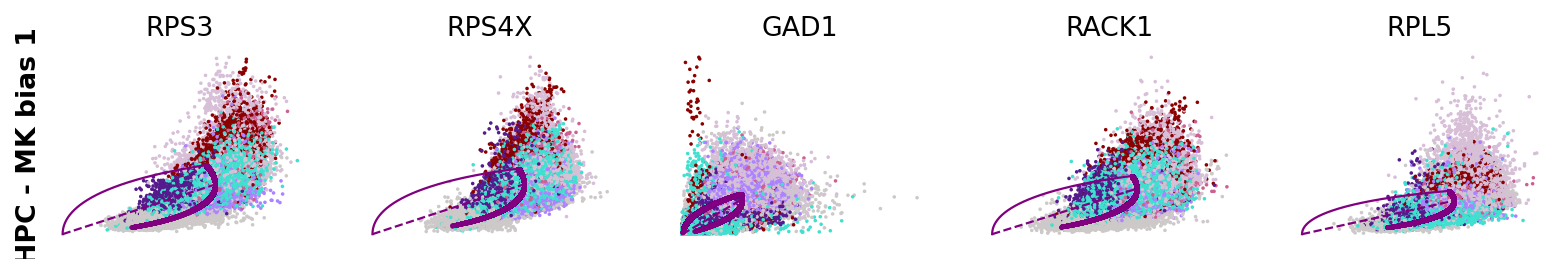

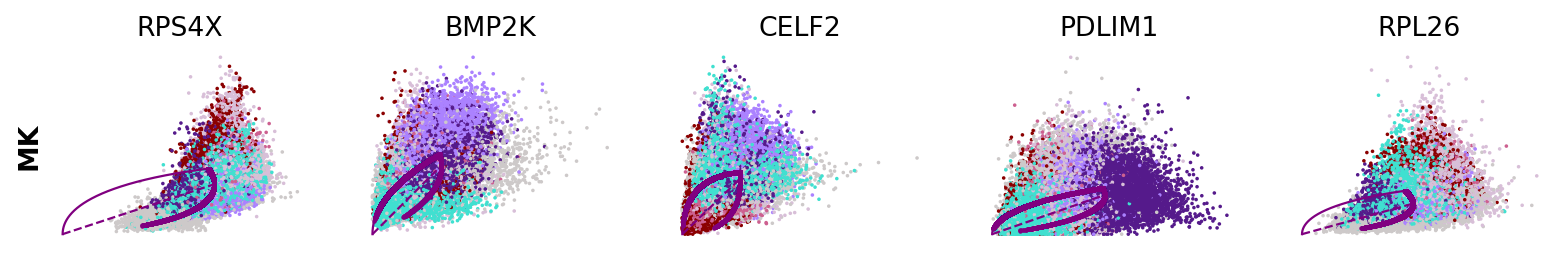

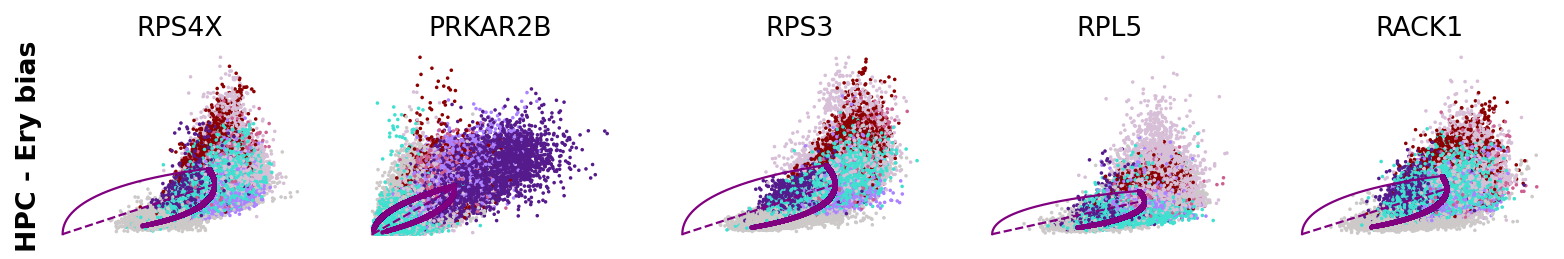

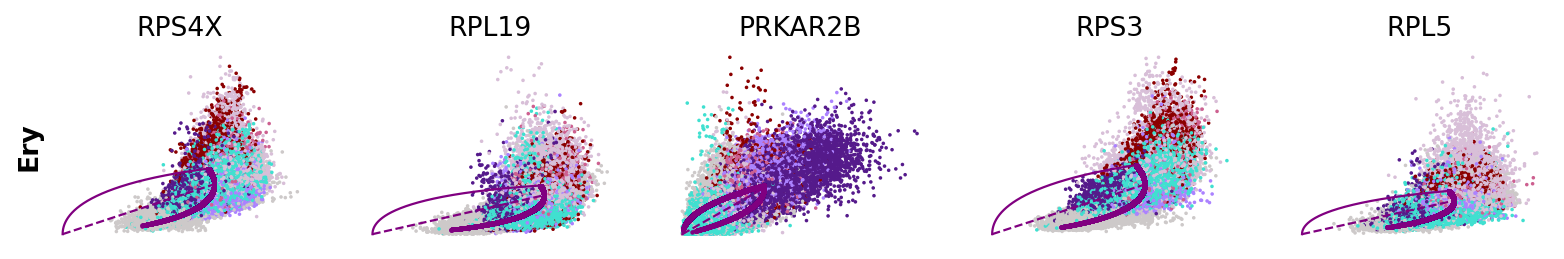

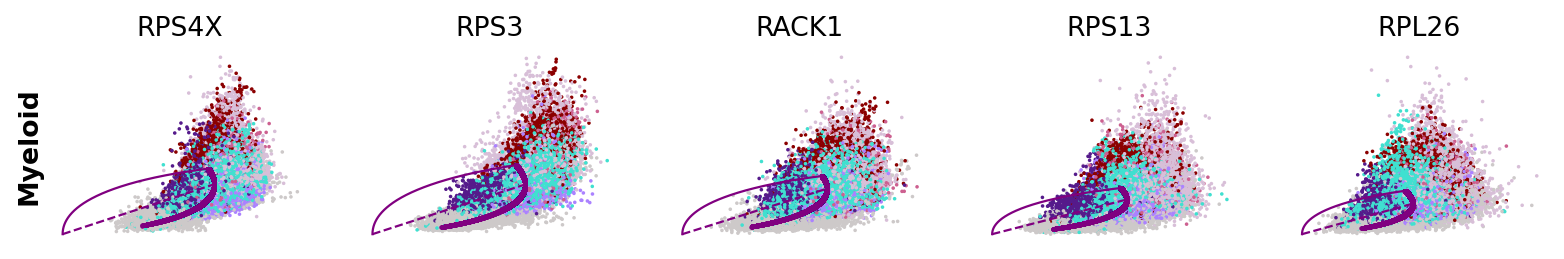

In [ ]:
warnings.filterwarnings('ignore')
for cluster in ['HPCs', 'HPC - MK bias 2', 'HPC - MK bias 1', 'MK', 'HPC - Ery bias', 'Ery', 'Myeloid']:
    scv.pl.scatter(adata, df[cluster][:5], ylabel=cluster, frameon=False, color='cell_type')

## Save velocity latent time analysis

In [ ]:
# save merged dataset as anndata format
adata.write("../seurat_objects/timecourse-d7911-renamed-merged-velocity-latenttime.h5ad")

In [ ]:
# reload dataset
adata = sc.read_h5ad("../seurat_objects/timecourse-d7911-renamed-merged-velocity-latenttime.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'rank_dynamical_genes', 'recover_dynamics', 'time_colors', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X

In [ ]:
adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score',
       'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time',
       'sample_batch', 'batch', 'initial_size_unspliced',
       'initial_size_spliced', 'initial_size', 'n_counts',
       'velocity_self_transition', 'root_cells', 'end_points',
       'velocity_pseudotime', 'latent_time'],
      dtype='object')

In [ ]:
adata.obs[['barcode', 'time', 'cell_type', 'condition', 'genotype', 'latent_time']].to_csv("../results/timecourse/timecourse-d7911-renamed-latent-time.csv.gz",
                                                         index=False)